In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
from IPython.display import clear_output
from joblib import Parallel, delayed
import pandas as pd
import statsmodels.api as sm
import itertools
import time


from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

### Global variables

In [11]:
# Element data
ELEMENTS = ['SIO2', 'TIO2', 'B2O3', 'AL2O3', 'CR2O3', 'FE2O3', 'FEO', 'FEOT', 'CAO', 'MGO',
            'MNO', 'NIO', 'K2O', 'NA2O', 'P2O5', 'H2O', 'CO2', 'CO1', 'F', 'CL', 'CL2', 'OH',
            'CH4', 'SO2', 'SO3', 'SO4', 'S', 'LI', 'BE', 'B', 'C', 'NA', 'MG',
            'AL', 'P', 'K', 'CA', 'SC', 'TI', 'V', 'CR', 'MN', 'FE', 'CO', 'NI', 'CU', 'ZN',
            'GA', 'GE', 'AS', 'SE', 'BR', 'RB', 'SR', 'Y', 'ZR', 'NB', 'MO', 'RU', 'RH', 'PD',
            'AG', 'CD', 'IN', 'SN', 'SB', 'TE', 'I', 'CS', 'BA', 'LA', 'CE', 'PR', 'ND', 'SM',
            'EU', 'GD', 'TB', 'DY', 'HO', 'ER', 'TM', 'YB', 'LU', 'HF', 'TA', 'W', 'RE', 'OS',
            'IR', 'PT', 'AU', 'HG', 'TL', 'PB', 'BI', 'TH', 'U'] 

PPM_ELEMENTS = ['LI', 'BE', 'B', 'C', 'NA', 'MG', 'AL', 'P', 'K', 'CA', 'SC', 
                'TI', 'V', 'CR', 'MN', 'FE', 'CO', 'NI', 'CU', 'ZN', 'GA', 'GE', 'AS', 'SE',
                'BR', 'RB', 'SR', 'Y', 'ZR', 'NB', 'MO', 'RU', 'RH', 'PD', 'AG', 'CD', 'IN',
                'SN', 'SB', 'TE', 'I', 'CS', 'BA', 'LA', 'CE', 'PR', 'ND', 'SM', 'EU', 'GD',
                'TB', 'DY', 'HO', 'ER', 'TM', 'YB', 'LU', 'HF', 'TA', 'W', 'RE', 'OS', 'IR',
                'PT', 'AU', 'HG', 'TL', 'PB', 'BI', 'TH', 'U']

REE_ELEMENTS = ['LA', 'CE', 'PR', 'ND', 'SM', 'EU', 'GD', 'TB', 'DY', 'HO', 'ER', 'TM', 'YB', 'LU']

REE_ELEMENTS_LAMBDA = ['LA', 'CE', 'PR', 'ND', 'SM', 'GD', 'TB', 'DY', 'HO', 'ER', 'TM', 'YB', 'LU'] # exclude Eu

ELEMENTS_MASS = {
    'SIO2': 60.08,'TIO2': 79.87,'B2O3': 69.62,'AL2O3': 101.96,'CR2O3': 151.99,'FE2O3': 159.69,'FEO': 71.85,'FEOT': 87.85,'CAO': 56.08,'MGO': 40.30,'MNO': 70.94,'NIO': 74.71,
    'K2O': 94.20,'NA2O': 61.98,'P2O5': 141.94,'H2O': 18.02,'CO2': 44.01,'CO1': 28.01,'F': 18.99,'CL': 35.45,'CL2': 70.90,'OH': 17.01,
    'CH4': 16.04,'SO2': 64.07,'SO3': 80.06,'SO4': 96.06,'S': 32.07,'LI': 6.94,'BE': 9.01,'B': 10.81,'C': 12.01,'NA': 22.99,'MG': 24.31,'AL': 26.98,
    'P': 30.97,'K': 39.10,'CA': 40.08,'SC': 44.96,'TI': 47.87,'V': 50.94,'CR': 52.00,'MN': 54.94,'FE': 55.85,'CO': 58.93,'NI': 58.69,'CU': 63.55,
    'ZN': 65.38,'GA': 69.72,'GE': 72.63,'AS': 74.92,'SE': 78.97,'BR': 79.90,'RB': 85.47,'SR': 87.62,'Y': 88.91,'ZR': 91.22,'NB': 92.91,'MO': 95.94,'RU': 101.07,'RH': 102.91,'PD': 106.42,'AG': 107.87,
    'CD': 112.41,'IN': 114.82,'SN': 118.71,'SB': 121.76,'TE': 127.60,'I': 126.90,'CS': 132.91,'BA': 137.33,'LA': 138.91,
    'CE': 140.12,'PR': 140.91,'ND': 144.24,'SM': 150.36,'EU': 151.96,'GD': 157.25,'TB': 158.93,'DY': 162.50,'HO': 164.93,
    'ER': 167.26,'TM': 168.93,'YB': 173.05,'LU': 174.97,'HF': 178.49,'TA': 180.95,'W': 183.84,'RE': 186.21,'OS': 190.23,
    'IR': 192.22,'PT': 195.08,'AU': 196.97,'HG': 200.59,'TL': 204.38,'PB': 207.2,'BI': 208.98,'TH': 232.04,'U': 238.03}

# External datasets
CI_DATA = pd.read_csv('DATA/lambda_parameters.csv')
VOLCANO_DATABASE = pd.read_csv('DATA/GVP_HOLOCENE_VOLCS.csv')
df = pd.read_csv('DATA/R_arcs_edited.csv', low_memory=False)

### FUNCTIONS

In [13]:
####### DATA PROCESSING FUNCTIONS

def clean_data(df, ELEMENTS):
    # replace zeros with nan
    df = df.replace(0, np.nan)
    # replace negative concentrations with np.nan
    df[ELEMENTS] = df[ELEMENTS].mask(df[ELEMENTS]<0)
    # drop any samples where SIO2 is not present (removes any trace element-only analyses, which messes with normalisation)
    df = df.dropna(subset = ['SIO2'])
    # drop any samples where LOI < 3.5 wt% (ie. totals <97.5%)
    df = df.loc[df["LOI"] <= 3.5]
    return df

def CI_norm_REE(df, REE_ELEMENTS, CI_DATA):
    CI = CI_DATA.set_index('ELEMENT')['CI_ppm']
    df = df.assign(**{f'{col}_CInorm': df[col] / CI[col] for col in REE_ELEMENTS})
    return df
    
def ppm_to_wt(i_ppm):
    return i_ppm / 10000
    
def convert_ppm2wtpc(df, PPM_ELEMENTS):
    df[PPM_ELEMENTS] = df[PPM_ELEMENTS].apply(ppm_to_wt)
    return df

def normalise_totals(df, ELEMENTS): # see whteher this is important
    df['calc_TOTAL'] = df[ELEMENTS].sum(axis=1) 
    df = df.assign(**{f'{col}_norm': df[col] / df['calc_TOTAL'] for col in ELEMENTS})
    return df

def molar_fraction(df, ELEMENTS, ELEMENTS_MASS):
    df = df.assign(**{f'{col}_mol': df[col] / ELEMENTS_MASS[col] for col in ELEMENTS})
    df['mol_TOT'] = df[ [f'{col}_mol' for col in ELEMENTS] ].sum(axis=1)
    df = df.assign(**{f'{col}_molfrac': df[f'{col}_mol'] / df['mol_TOT'] for col in ELEMENTS})
    df = df.drop([f'{col}_mol' for col in ELEMENTS], axis='columns')
    df = df.drop(['mol_TOT'], axis='columns')
    return df
    
def CLR_transform(df, ELEMENTS):
    ELEMENTS_norm = [f'{i}_norm' for i in ELEMENTS]
    df['geom_mean'] = np.exp(np.log(df[ELEMENTS_norm]).mean(axis=1))
    df = df.assign(**{f'{col}_clr': np.log(df[col] / df['geom_mean']) for col in ELEMENTS})
    return df

########## GEOCHEMICAL CLASSIFICATIONS

def MG_number(mgo, feo, fe2o3, feot):
    if feot != np.nan:
        iron = feot
    else:
        iron = feo + fe2o3
    value = mgo / (mgo + iron)
    return value

def class_SIO2(sio2):
    if sio2 <= 0.45:
        value = 'ultrabasic'
    elif sio2 <= 0.52:
        value = 'basic'
    elif sio2 <= 0.63:
        value = 'intermediate'
    else:
        value = 'acid'
    return value

def class_alkalic(sio2, na2o, k2o):
    if sio2 > 0.774:
        value = np.nan
    else:
        TA = na2o + k2o
        boundary_x = [0.392, 0.40, 0.432, 0.45, 0.48, 0.50, 0.537, 0.55, 0.60, 0.65, 0.774]
        boundary_y = [0, 0.04, 0.02, 0.028, 0.04, 0.0475, 0.06, 0.064, 0.08, 0.096, 0.10]
        TA_threshold = np.interp(sio2, boundary_x, boundary_y)
        if TA <= TA_threshold:
            value = 'sub-alkalic'
        else:
            value = 'alkalic'
    return value

def class_LeMaitre(sio2, k2o):
    low_med_boundary = [0.045, -0.0186] # slope, intercept
    med_high_boundary = [0.095, -0.0336] # slope, intercept
    
    if sio2 < 0.48:
        value = np.nan
    else:
        med_threshold = sio2 * low_med_boundary[0] + low_med_boundary[1]
        max_threshold = sio2 * med_high_boundary[0] + med_high_boundary[1]
        if k2o <= med_threshold:
            value = 'low-K'
        elif k2o <= max_threshold:
            value = 'medium-K'
        else:
            value = 'high-K'
    return value

def Fe_index(sio2, feo, fe2o3, feot, mgo):
    if feot != np.nan:
        iron = feot
    else:
        iron = feo + fe2o3
    fe_index = iron / (iron + mgo)
    return fe_index

def class_Fe_index(fe_index, sio2):
    threshold = 0.46 + (0.005 * sio2)
    if fe_index <= threshold:
        value = 'magnesian'
    else:
        value = 'ferroan'
    return value

def peralkalinity_index(na_mol, k_mol, al_mol):
    return (na_mol + k_mol) / al_mol

# def calc_REE_lambdas(df, REE_ELEMENTS, CI_DATA):
#     REE_radii = CI_DATA.reset_index('ELEMENT')['R_amstrong']

### DATABASE PREPARATION

In [16]:
# Process
df = clean_data(df, ELEMENTS)
df = CI_norm_REE(df, REE_ELEMENTS, CI_DATA)
df = convert_ppm2wtpc(df, PPM_ELEMENTS)
df = normalise_totals(df, ELEMENTS) # normalises to 1 (ie. wt fraction)
df = molar_fraction(df, ELEMENTS, ELEMENTS_MASS)

# Transform
df = CLR_transform(df, ELEMENTS)

# Calculate additional variables
df['MG_no'] = df.apply(lambda x: MG_number(x['MGO_norm'], x['FEO_norm'], x['FE2O3_norm'], x['FEOT_norm']), axis=1)
df['class_SIO2'] = df.apply(lambda x: class_SIO2(x['SIO2_norm']), axis=1)
df['class_alkalic'] = df.apply(lambda x: class_alkalic(x['SIO2_norm'], x['NA2O_norm'], x['K2O_norm']), axis=1)
df['class_LeMaitre'] = df.apply(lambda x: class_LeMaitre(x['SIO2_norm'], x['K2O_norm']), axis=1)
df['Fe_index'] = df.apply(lambda x: Fe_index(x['SIO2_norm'], x['FEO_norm'], x['FE2O3_norm'], x['FEOT_norm'], x['MGO_norm']), axis=1)
df['class_Fe_index'] = df.apply(lambda x: class_Fe_index(x['Fe_index'], x['SIO2_norm']), axis=1)
df['peralkalinity_index'] = df.apply(lambda x: peralkalinity_index(x['NA2O_molfrac'], x['K2O_molfrac'], x['AL2O3_molfrac']), axis=1)

# Transform
df = CLR_transform(df, ELEMENTS)

# Save to csv
df.to_csv('DATA/georoc_arcs_modified.csv')

### Lambda function development

In [243]:
test_data = df.loc[df['LOCATION'] == df['LOCATION'].unique()[0]]

test_data_fit = test_data.drop('EU_CInorm', axis='columns') # drop Eu from the elements dataframe
CI_DATA_LAMBDA = CI_DATA.drop(CI_DATA.loc[CI_DATA['ELEMENT'] == 'EU'].index) # drop Eu from the elemet radii dataframe

CI_REES = [f'{i}_CInorm' for i in REE_ELEMENTS_LAMBDA] # define list of column names for REE elements
REE_radii = CI_DATA_LAMBDA.set_index('ELEMENT')['R_amstrong'] # get the list of relevant atomic radii

yvals = np.log(test_data.loc[[19]][CI_REES].values[0]) # natural log of the CI normalised concentrations ([19] just to pick one row for testing)
xvals = REE_radii.to_list()

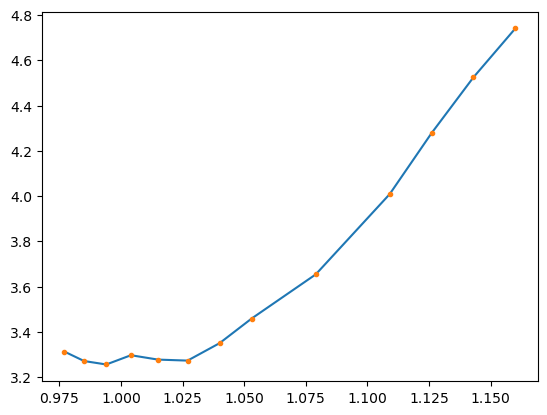

In [237]:
plt.plot(xvals, yvals)
plt.plot(xvals, yvals, '.')
plt.show()